In [ ]:
from lorenzo_utils import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

graph_path = DATA_DIR + 'Centrality/Centrality_climate_19.graphml'
G = load_graph(graph_path)


/home/lore/PyProjects/Networks/AVRC_FinnishTwittersphereProject/Lorenzo/lorenzo_utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


In [2]:
COMPUTE_CENTRALITY = False
if COMPUTE_CENTRALITY:
    from sys import stdout
    for graph_file in GRAPH_FILENAMES:
        print('loading:', graph_file)
        stdout.flush()
        G = load_graph(DATA_DIR + graph_file)
        load_all_centralities(G, dumpfile=DATA_DIR+'Centrality/Centrality_'+graph_file)
        print('saved centrality')

In [29]:
def plot_ccdf(G: ig.Graph, metric: str='degree', log: bool=True):
    values = np.array(G.vs[metric])
    k_values, ccdf = compute_ccdf(values)
    kA_values, ccdfA = compute_ccdf(values[[group == 'A' for group in G.vs['group']]])
    kB_values, ccdfB = compute_ccdf(values[[group == 'B' for group in G.vs['group']]])

    fig, ax = plt.subplots(figsize=(6,4), sharex=True, layout='tight')
    ax.plot(k_values, ccdf, marker='.', linewidth='2', markersize='0.3', color = cmap(0), label='Tot')
    ax.plot(kA_values, ccdfA, marker='.', linewidth='2', markersize='0.3', color = cmap(1), label='A')
    ax.plot(kB_values, ccdfB, marker='.', linewidth='2', markersize='0.3', color = cmap(2), label='B')
    ax.set_title(metric + ' complementary cumulative distribution')
    ax.set_xlabel(metric)
    ax.set_ylabel('ccdf')
    fig.legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')
    return k_values, ccdf

def scatter_centrality(G: ig.Graph, metric: str='degree', log: bool=True):
    values = np.array(G.vs[metric])
    values_count = np.unique_counts(values)
    P_x = values_count.counts / len(values)
    
    # kA_values, ccdfA = compute_ccdf(values[[group == 'A' for group in G.vs['group']]])
    # kB_values, ccdfB = compute_ccdf(values[[group == 'B' for group in G.vs['group']]])

    fig, ax = plt.subplots(figsize=(6,4), sharex=True, layout='tight')
    ax.scatter(values_count.values, P_x, color = cmap(0), label='Tot', alpha=0.8)
    # ax.plot(kA_values, ccdfA, marker='.', linewidth='2', markersize='0.3', color = cmap(1), label='A')
    # ax.plot(kB_values, ccdfB, marker='.', linewidth='2', markersize='0.3', color = cmap(2), label='B')
    ax.set_title(metric + ' complementary cumulative distribution')
    ax.set_xlabel(metric)
    ax.set_ylabel('ccdf')
    # fig.legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')
    return {'values': values_count.values, 'probability': P_x, 'ax': ax}

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 149/149 [00:00<00:00, 308.17it/s]


Esponente alpha: 1.80869275000628
x_min ottimale: 1.0
R: -142.09186573302043, p-value: 1.692373592225245e-39


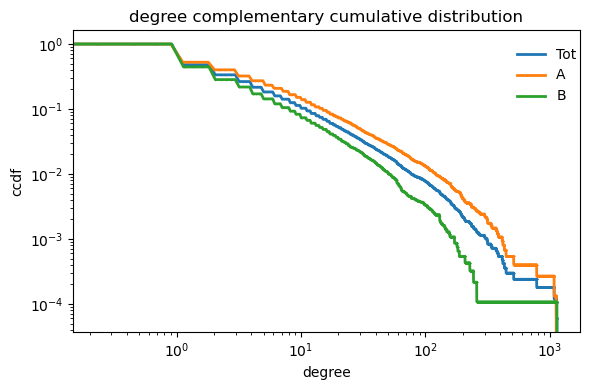

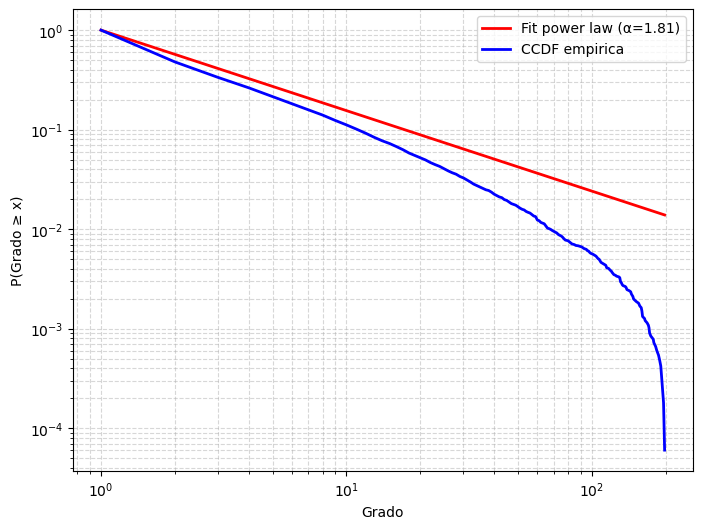

In [9]:
import powerlaw
import numpy as np

FIT_INTERVAL = (0,200)

degrees = np.array(G.vs['degree'])
degrees = degrees[(degrees < FIT_INTERVAL[1]) & (degrees > FIT_INTERVAL[0])]
plot_ccdf(G, 'degree')


# Supponiamo che 'data' sia il tuo array di gradi
fit = powerlaw.Fit(degrees, discrete=True)

# Ottieni l'esponente alpha
print(f"Esponente alpha: {fit.power_law.alpha}")

# Ottieni il valore x_min scelto automaticamente
print(f"x_min ottimale: {fit.power_law.xmin}")

# Estrai i punti della CCDF empirica dal fit (sono quelli dei dati originali)
x_ccdf, y_ccdf = fit.ccdf()

# Puoi anche confrontare se è davvero una power law
# (es. rispetto a una distribuzione log-normale o esponenziale)
R, p = fit.distribution_compare('power_law', 'lognormal', nested=False)
print(f"R: {R}, p-value: {p}")

alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

# Trova il valore di y_ccdf esattamente (o il più vicino) a xmin
idx = np.argmin(np.abs(x_ccdf - xmin))
y_at_xmin = y_ccdf[idx]

# Ascisse per la curva teorica: da xmin fino al massimo grado che compare nei dati
x_max = max(degrees)
x_theory = np.linspace(xmin, x_max, 100)
y_theory = (x_theory / xmin) ** (-(alpha - 1)) * y_at_xmin

plt.figure(figsize=(8, 6))

# Curva teorica
plt.loglog(x_theory, y_theory, 'r-', linewidth=2, label=f'Fit power law (α={alpha:.2f})')

# CCDF empirica completa
plt.loglog(x_ccdf, y_ccdf, 'b-', linewidth=2, label='CCDF empirica')

# (Opzionale) evidenzia i punti usati per il fit
# plt.loglog(in_vals, in_ccdf, 'go', markersize=3, alpha=0.5)

plt.xlabel('Grado')
plt.ylabel('P(Grado ≥ x)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

Esponente alpha: -1.2579699156487745
R: -0.9842822724183861, p-value: 0.0


/tmp/ipykernel_21086/2235291096.py:17: RuntimeWarning: divide by zero encountered in log10
  y_theory = intercept + slope * np.log10(vals)
/tmp/ipykernel_21086/2235291096.py:22: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(vals), y_theory, 'r-', linewidth=2, label=f'Fit power law (α={slope:.2f})')
/tmp/ipykernel_21086/2235291096.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(vals), np.log10(ccdf), 'b-', linewidth=2, label='CCDF empirica')


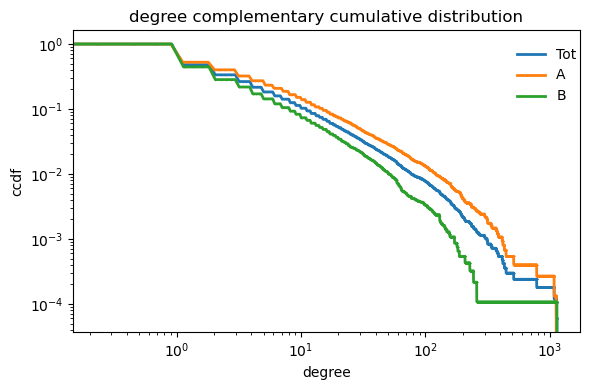

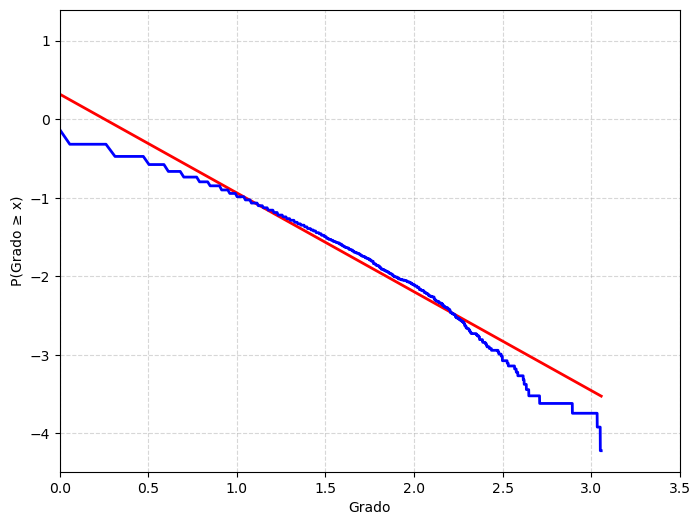

In [ ]:
FIT_INTERVAL = (0,250)
vals, ccdf = plot_ccdf(G, 'degree')
in_vals_m = (vals > FIT_INTERVAL[0]) & (vals < FIT_INTERVAL[1])
in_vals = np.log10(vals[in_vals_m])
in_ccdf = np.log10(ccdf[in_vals_m])
slope, intercept, R, p, err = linregress(in_vals, in_ccdf)

# Ottieni l'esponente alpha
print(f"Esponente alpha: {slope}")
# Stampa i parametri di controllo
print(f"R: {R}, p-value: {p}")

# Ordinate per la curva teorica
y_theory = intercept + slope * np.log10(vals)

plt.figure(figsize=(8, 6))

# Curva teorica
plt.plot(np.log10(vals), y_theory, 'r-', linewidth=2, label=f'Fit power law (α={slope:.2f})')

# CCDF empirica completa
plt.plot(np.log10(vals), np.log10(ccdf), 'b-', linewidth=2, label='CCDF empirica')

plt.xlim(0,3.5)

plt.xlabel('Grado')
plt.ylabel('P(Grado ≥ x)')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()


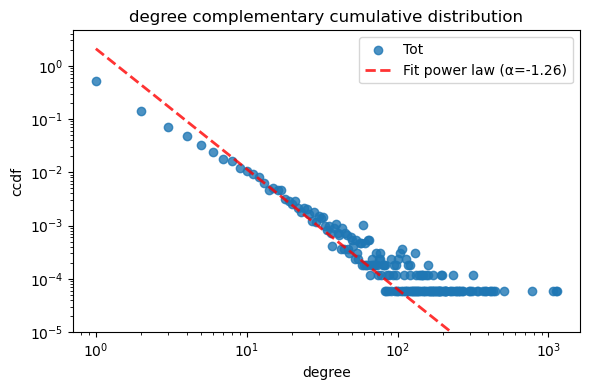

In [ ]:
scatter_plot = scatter_centrality(G)
# Ordinate per la curva teorica
y_theory = 10**intercept * (scatter_plot['values'] ** (slope-1))
# Curva teorica
scatter_plot['ax'].plot(scatter_plot['values'], y_theory, 'r--', linewidth=2, label=f'Fit power law (α={(slope-1):.2f})', alpha=0.8)
scatter_plot['ax'].set_ylim(0.00001)
scatter_plot['ax'].legend()


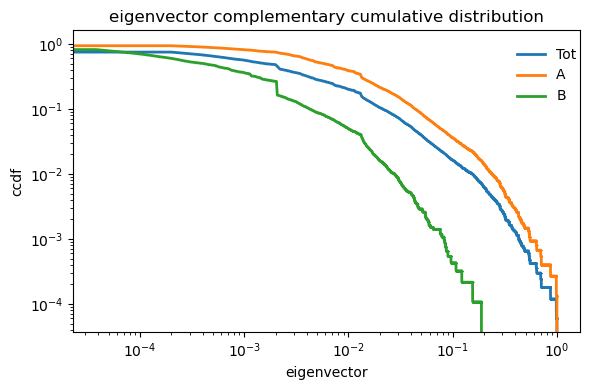

In [ ]:
plot_ccdf(G, 'eigenvector')

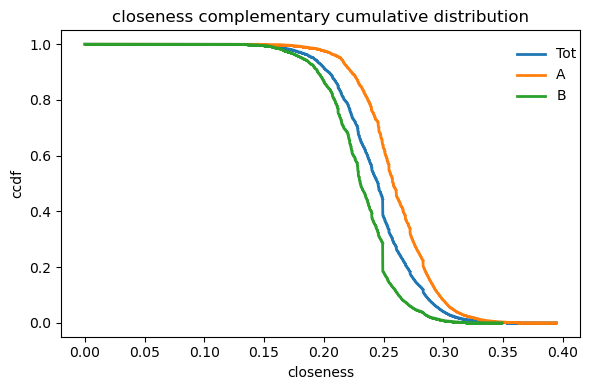

In [26]:
plot_ccdf(G, 'closeness', log=False)

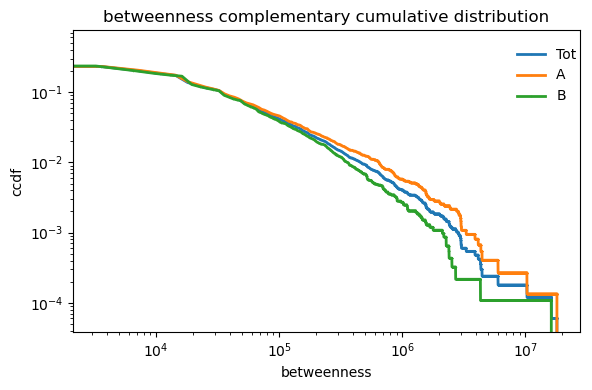

In [ ]:
plot_ccdf(G, 'betweenness', log=True)